# DATA ANALYSIS
**This notebook will be used for ploting and data analysis for the final report**

In [2]:
import sys
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.utils.plot_tools import (
    load_summary_csv,
    merge_accuracy_runtime,
    plot_accuracy_bar,
    plot_runtime_bar,
    plot_tradeoff_scatter,
    plot_stability_errorbar,
)

In [3]:
accuracy_df = load_summary_csv(project_root / "results" / "tables" / "final_accuracy_summary.csv")
runtime_df = load_summary_csv(project_root / "results" / "tables" / "final_runtime_summary.csv")
merged_df = merge_accuracy_runtime(accuracy_df, runtime_df)

model_order = ["GCN_baseline", "ELPH", "BUDDY"]

print("Accuracy summary shape:", accuracy_df.shape)
print("Runtime summary shape :", runtime_df.shape)
print("Merged summary shape  :", merged_df.shape)

display(accuracy_df)
display(runtime_df)

Accuracy summary shape: (8, 32)
Runtime summary shape : (8, 14)
Merged summary shape  : (8, 43)


,dataset,model,cfg_name,metric_name,monitor,monitor_hits_k,n_seeds,seeds,val_loss_mean,val_loss_std,...,val_ap_display,test_ap_mean,test_ap_std,test_ap_display,val_hits@K_mean,val_hits@K_std,val_hits@K_display,test_hits@K_mean,test_hits@K_std,test_hits@K_display
0,Collab,GCN_baseline,COLLAB_BASELINE,hits@50,val_hits@K,50,3,"1,2,3",0.332682,0.160042,...,0.95±0.02,0.948339,0.023870,0.95±0.02,0.110043,0.012394,0.11±0.01,0.071515,0.007813,0.07±0.01
1,Collab,BUDDY,COLLAB_BUDDY_PRIMARY,hits@50,val_hits@K,50,3,"1,2,3",0.311655,0.005912,...,0.98±0.00,0.977141,0.000788,0.98±0.00,0.855046,0.010813,0.86±0.01,0.737479,0.024400,0.74±0.02
2,Cora,GCN_baseline,CORA_BASELINE,hits@100,val_hits@K,100,3,"1,2,3",1.022748,0.328247,...,0.92±0.00,0.929232,0.001641,0.93±0.00,0.860215,0.011594,0.86±0.01,0.795261,0.025663,0.80±0.03
3,Cora,BUDDY,CORA_BUDDY_PRIMARY,hits@100,val_hits@K,100,3,"1,2,3",0.656232,0.012655,...,0.89±0.01,0.901379,0.004218,0.90±0.00,0.777356,0.017218,0.78±0.02,0.705529,0.017097,0.71±0.02
4,Cora,ELPH,CORA_ELPH_PRIMARY,hits@100,val_hits@K,100,3,"1,2,3",0.568092,0.006986,...,0.86±0.01,0.872083,0.014298,0.87±0.01,0.721063,0.012443,0.72±0.01,0.685308,0.006635,0.69±0.01
5,Pubmed,GCN_baseline,PUBMED_BASELINE,hits@100,val_hits@K,100,3,"1,2,3",0.334896,0.014522,...,0.94±0.00,0.943587,0.004166,0.94±0.00,0.546255,0.022167,0.55±0.02,0.395344,0.026896,0.40±0.03
6,Pubmed,BUDDY,PUBMED_BUDDY_PRIMARY,hits@100,val_hits@K,100,3,"1,2,3",0.582936,0.010973,...,0.92±0.01,0.921853,0.006849,0.92±0.01,0.580701,0.015270,0.58±0.02,0.504137,0.013523,0.50±0.01
7,Pubmed,ELPH,PUBMED_ELPH_PRIMARY,hits@100,val_hits@K,100,3,"1,2,3",0.640644,0.108373,...,0.90±0.02,0.916029,0.014867,0.92±0.01,0.507070,0.024972,0.51±0.02,0.447879,0.087265,0.45±0.09


,dataset,model,cfg_name,n_seeds,seeds,preprocess_sec_mean,preprocess_sec_std,preprocess_sec_display,train_sec_mean,train_sec_std,train_sec_display,inference_sec_mean,inference_sec_std,inference_sec_display
0,Collab,GCN_baseline,COLLAB_BASELINE,3,"1,2,3",0.000000,0.000000,0.000±0.000,0.087292,0.000418,0.087±0.000,0.163879,0.002420,0.164±0.002
1,Collab,BUDDY,COLLAB_BUDDY_PRIMARY,3,"1,2,3",139.329503,1.066042,139.330±1.066,75.518069,0.312796,75.518±0.313,0.573781,0.002045,0.574±0.002
2,Cora,GCN_baseline,CORA_BASELINE,3,"1,2,3",0.000000,0.000000,0.000±0.000,0.003909,0.000419,0.004±0.000,0.012962,0.001253,0.013±0.001
3,Cora,BUDDY,CORA_BUDDY_PRIMARY,3,"1,2,3",1.518381,0.160629,1.518±0.161,0.016133,0.001862,0.016±0.002,0.040930,0.005702,0.041±0.006
4,Cora,ELPH,CORA_ELPH_PRIMARY,3,"1,2,3",0.000000,0.000000,0.000±0.000,1.689303,0.148531,1.689±0.149,6.628993,0.618201,6.629±0.618
5,Pubmed,GCN_baseline,PUBMED_BASELINE,3,"1,2,3",0.000000,0.000000,0.000±0.000,0.005743,0.000293,0.006±0.000,0.024847,0.002527,0.025±0.003
6,Pubmed,BUDDY,PUBMED_BUDDY_PRIMARY,3,"1,2,3",10.837790,1.162305,10.838±1.162,0.043473,0.000138,0.043±0.000,0.068839,0.003486,0.069±0.003
7,Pubmed,ELPH,PUBMED_ELPH_PRIMARY,3,"1,2,3",0.000000,0.000000,0.000±0.000,11.477639,1.018722,11.478±1.019,47.105888,2.209008,47.106±2.209


## ACCURACY

In [4]:
for dataset in ["Cora", "Pubmed", "Collab"]:
    print(f"\n=== {dataset} ===")
    display(
        accuracy_df[accuracy_df["dataset"] == dataset][
            [
                "dataset",
                "model",
                "cfg_name",
                "n_seeds",
                "seeds",
                "test_auc_mean",
                "test_ap_mean",
                "test_hits@K_mean",
                "test_hits@K_std",
                "test_hits@K_display",
            ]
        ].sort_values("model")
    )


=== Cora ===


,dataset,model,cfg_name,n_seeds,seeds,test_auc_mean,test_ap_mean,test_hits@K_mean,test_hits@K_std,test_hits@K_display
3,Cora,BUDDY,CORA_BUDDY_PRIMARY,3,"1,2,3",0.881295,0.901379,0.705529,0.017097,0.71±0.02
4,Cora,ELPH,CORA_ELPH_PRIMARY,3,"1,2,3",0.866268,0.872083,0.685308,0.006635,0.69±0.01
2,Cora,GCN_baseline,CORA_BASELINE,3,"1,2,3",0.921451,0.929232,0.795261,0.025663,0.80±0.03



=== Pubmed ===


,dataset,model,cfg_name,n_seeds,seeds,test_auc_mean,test_ap_mean,test_hits@K_mean,test_hits@K_std,test_hits@K_display
6,Pubmed,BUDDY,PUBMED_BUDDY_PRIMARY,3,"1,2,3",0.914999,0.921853,0.504137,0.013523,0.50±0.01
7,Pubmed,ELPH,PUBMED_ELPH_PRIMARY,3,"1,2,3",0.910267,0.916029,0.447879,0.087265,0.45±0.09
5,Pubmed,GCN_baseline,PUBMED_BASELINE,3,"1,2,3",0.947295,0.943587,0.395344,0.026896,0.40±0.03



=== Collab ===


,dataset,model,cfg_name,n_seeds,seeds,test_auc_mean,test_ap_mean,test_hits@K_mean,test_hits@K_std,test_hits@K_display
1,Collab,BUDDY,COLLAB_BUDDY_PRIMARY,3,"1,2,3",0.959551,0.977141,0.737479,0.024400,0.74±0.02
0,Collab,GCN_baseline,COLLAB_BASELINE,3,"1,2,3",0.955364,0.948339,0.071515,0.007813,0.07±0.01


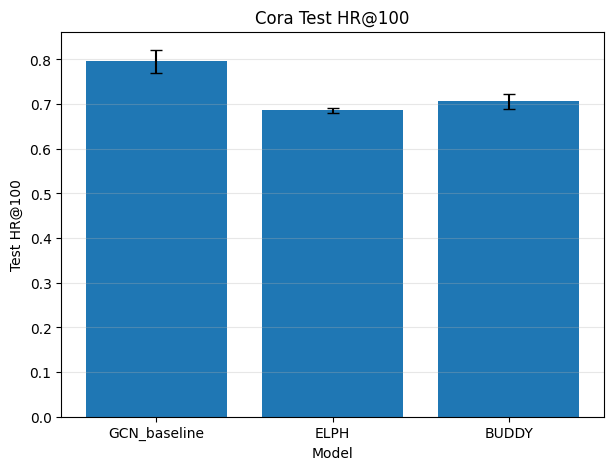

In [5]:
plot_accuracy_bar(
    accuracy_df=accuracy_df,
    dataset="Cora",
    metric_col="test_hits@K_mean",
    error_col="test_hits@K_std",
    model_order=model_order,
    save_path=project_root / "results" / "plots" / "cora_accuracy_bar.png",
    title="Cora Test HR@100",
    ylabel="Test HR@100",
)

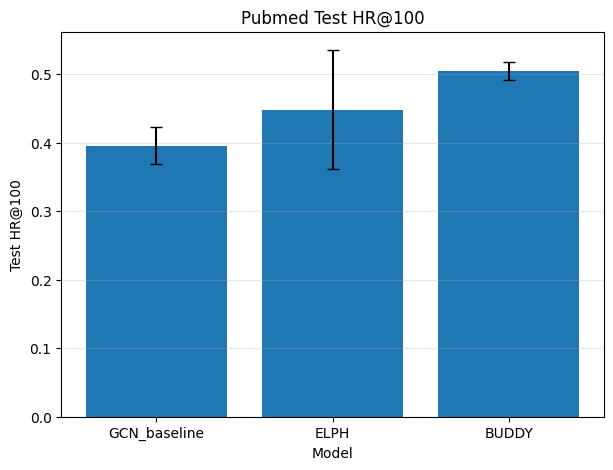

In [6]:
plot_accuracy_bar(
    accuracy_df=accuracy_df,
    dataset="Pubmed",
    metric_col="test_hits@K_mean",
    error_col="test_hits@K_std",
    model_order=model_order,
    save_path=project_root / "results" / "plots" / "pubmed_accuracy_bar.png",
    title="Pubmed Test HR@100",
    ylabel="Test HR@100",
)

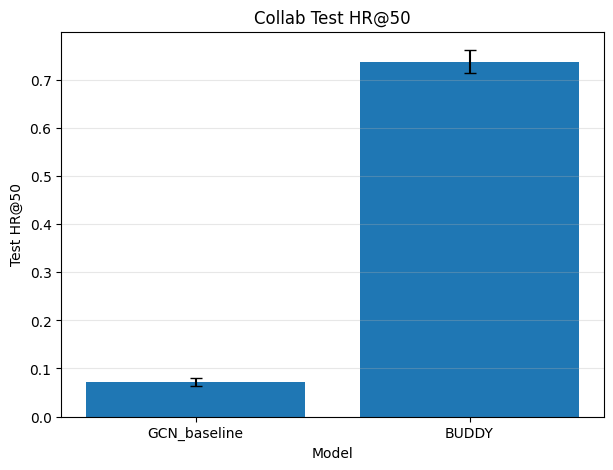

In [7]:
plot_accuracy_bar(
    accuracy_df=accuracy_df,
    dataset="Collab",
    metric_col="test_hits@K_mean",
    error_col="test_hits@K_std",
    model_order=model_order,
    save_path=project_root / "results" / "plots" / "collab_accuracy_bar.png",
    title="Collab Test HR@50",
    ylabel="Test HR@50",
)

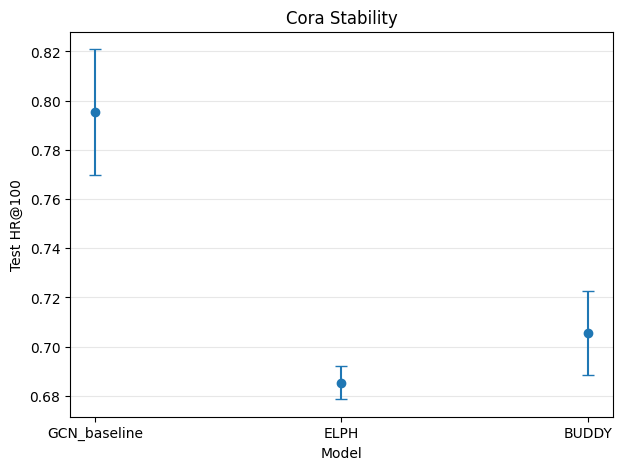

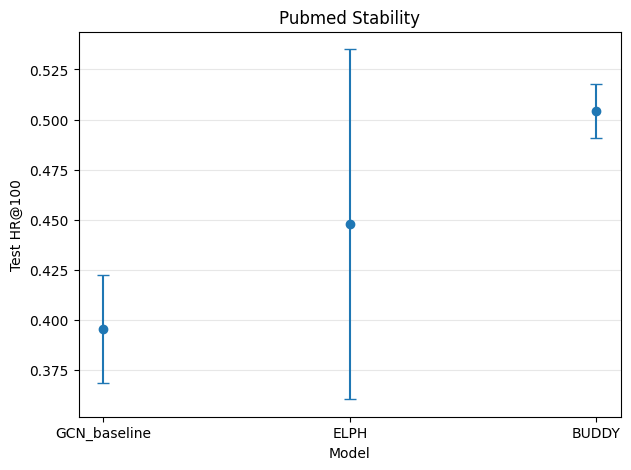

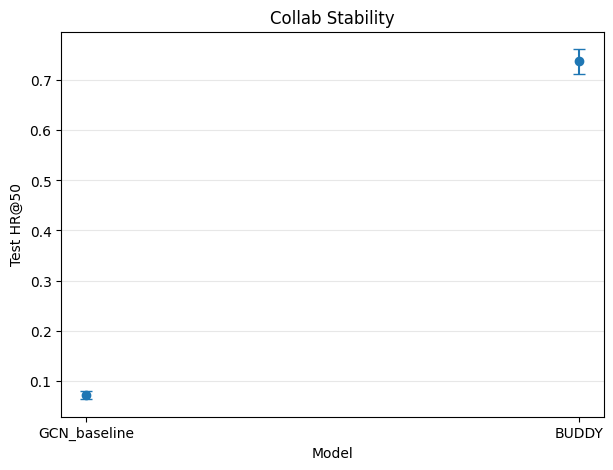

In [8]:
for dataset, ylabel in [("Cora", "Test HR@100"), ("Pubmed", "Test HR@100"), ("Collab", "Test HR@50")]:
    plot_stability_errorbar(
        accuracy_df=accuracy_df,
        dataset=dataset,
        mean_col="test_hits@K_mean",
        std_col="test_hits@K_std",
        model_order=model_order,
        save_path=project_root / "results" / "plots" / f"{dataset.lower()}_stability.png",
        title=f"{dataset} Stability",
        ylabel=ylabel,
    )

## RUNTIME

In [9]:
for dataset in ["Cora", "Pubmed", "Collab"]:
    print(f"\n=== {dataset} ===")
    display(
        runtime_df[runtime_df["dataset"] == dataset][
            [
                "dataset",
                "model",
                "cfg_name",
                "n_seeds",
                "seeds",
                "preprocess_sec_mean",
                "preprocess_sec_std",
                "train_sec_mean",
                "train_sec_std",
                "inference_sec_mean",
                "inference_sec_std",
            ]
        ].sort_values("model")
    )


=== Cora ===


,dataset,model,cfg_name,n_seeds,seeds,preprocess_sec_mean,preprocess_sec_std,train_sec_mean,train_sec_std,inference_sec_mean,inference_sec_std
3,Cora,BUDDY,CORA_BUDDY_PRIMARY,3,"1,2,3",1.518381,0.160629,0.016133,0.001862,0.040930,0.005702
4,Cora,ELPH,CORA_ELPH_PRIMARY,3,"1,2,3",0.000000,0.000000,1.689303,0.148531,6.628993,0.618201
2,Cora,GCN_baseline,CORA_BASELINE,3,"1,2,3",0.000000,0.000000,0.003909,0.000419,0.012962,0.001253



=== Pubmed ===


,dataset,model,cfg_name,n_seeds,seeds,preprocess_sec_mean,preprocess_sec_std,train_sec_mean,train_sec_std,inference_sec_mean,inference_sec_std
6,Pubmed,BUDDY,PUBMED_BUDDY_PRIMARY,3,"1,2,3",10.83779,1.162305,0.043473,0.000138,0.068839,0.003486
7,Pubmed,ELPH,PUBMED_ELPH_PRIMARY,3,"1,2,3",0.00000,0.000000,11.477639,1.018722,47.105888,2.209008
5,Pubmed,GCN_baseline,PUBMED_BASELINE,3,"1,2,3",0.00000,0.000000,0.005743,0.000293,0.024847,0.002527



=== Collab ===


,dataset,model,cfg_name,n_seeds,seeds,preprocess_sec_mean,preprocess_sec_std,train_sec_mean,train_sec_std,inference_sec_mean,inference_sec_std
1,Collab,BUDDY,COLLAB_BUDDY_PRIMARY,3,"1,2,3",139.329503,1.066042,75.518069,0.312796,0.573781,0.002045
0,Collab,GCN_baseline,COLLAB_BASELINE,3,"1,2,3",0.000000,0.000000,0.087292,0.000418,0.163879,0.002420


## TRADEOFF

In [12]:
display(
    merged_df[
        [
            "dataset",
            "model",
            "cfg_name",
            "test_hits@K_mean",
            "test_hits@K_std",
            "train_sec_mean",
            "inference_sec_mean",
            "preprocess_sec_mean",
        ]
    ].sort_values(["dataset", "model"])
)

,dataset,model,cfg_name,test_hits@K_mean,test_hits@K_std,train_sec_mean,inference_sec_mean,preprocess_sec_mean
1,Collab,BUDDY,COLLAB_BUDDY_PRIMARY,0.737479,0.024400,75.518069,0.573781,139.329503
0,Collab,GCN_baseline,COLLAB_BASELINE,0.071515,0.007813,0.087292,0.163879,0.000000
3,Cora,BUDDY,CORA_BUDDY_PRIMARY,0.705529,0.017097,0.016133,0.040930,1.518381
4,Cora,ELPH,CORA_ELPH_PRIMARY,0.685308,0.006635,1.689303,6.628993,0.000000
2,Cora,GCN_baseline,CORA_BASELINE,0.795261,0.025663,0.003909,0.012962,0.000000
6,Pubmed,BUDDY,PUBMED_BUDDY_PRIMARY,0.504137,0.013523,0.043473,0.068839,10.837790
7,Pubmed,ELPH,PUBMED_ELPH_PRIMARY,0.447879,0.087265,11.477639,47.105888,0.000000
5,Pubmed,GCN_baseline,PUBMED_BASELINE,0.395344,0.026896,0.005743,0.024847,0.000000


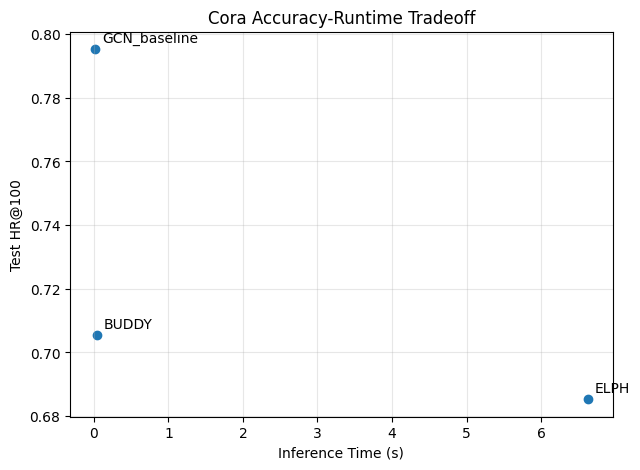

In [13]:
plot_tradeoff_scatter(
    merged_df=merged_df,
    dataset="Cora",
    x_col="inference_sec_mean",
    y_col="test_hits@K_mean",
    model_order=model_order,
    save_path=project_root / "results" / "plots" / "cora_tradeoff.png",
    title="Cora Accuracy-Runtime Tradeoff",
    xlabel="Inference Time (s)",
    ylabel="Test HR@100",
)

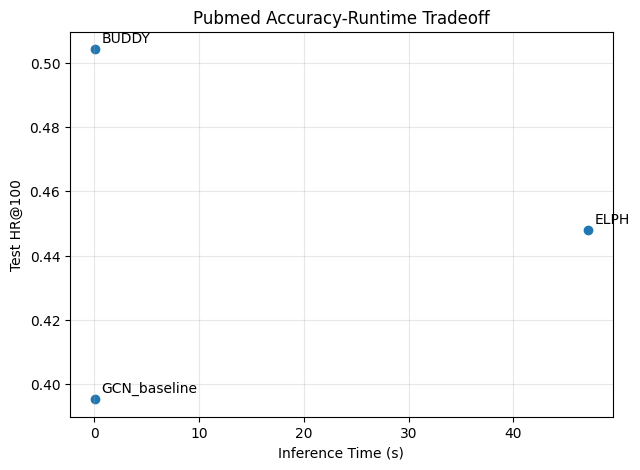

In [14]:
plot_tradeoff_scatter(
    merged_df=merged_df,
    dataset="Pubmed",
    x_col="inference_sec_mean",
    y_col="test_hits@K_mean",
    model_order=model_order,
    save_path=project_root / "results" / "plots" / "pubmed_tradeoff.png",
    title="Pubmed Accuracy-Runtime Tradeoff",
    xlabel="Inference Time (s)",
    ylabel="Test HR@100",
)

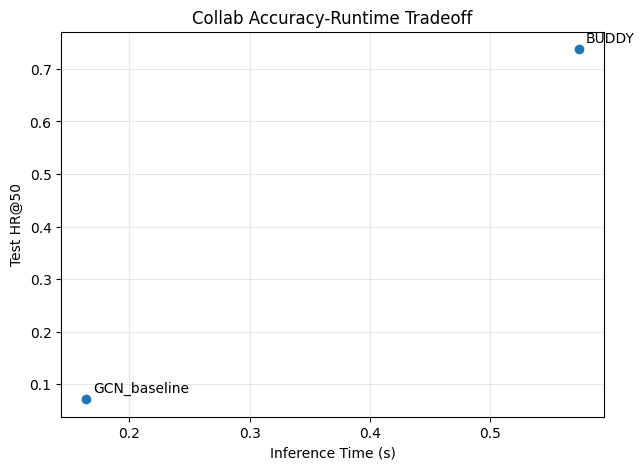

In [15]:
plot_tradeoff_scatter(
    merged_df=merged_df,
    dataset="Collab",
    x_col="inference_sec_mean",
    y_col="test_hits@K_mean",
    model_order=model_order,
    save_path=project_root / "results" / "plots" / "collab_tradeoff.png",
    title="Collab Accuracy-Runtime Tradeoff",
    xlabel="Inference Time (s)",
    ylabel="Test HR@50",
)

## Best Checkpoints:

In [21]:
import json

rows = []
raw_json_dir = project_root / "results" / "raw_json"
for path in raw_json_dir.glob("*.json"):
    if path.stem.endswith("_runtime"):
        continue

    with open(path, "r", encoding="utf-8") as f:
        row = json.load(f)

    row["json_path"] = str(path)
    row["checkpoint_path"] = str(project_root / "results" / "models" / f"{row['cfg_name']}_seed{row['seed']}.pt")
    rows.append(row)

raw_df = pd.DataFrame(rows)

best_ckpt_df = (
    raw_df.sort_values(["dataset", "model", "test_hits@K"], ascending=[True, True, False])
    .groupby(["dataset", "model"], as_index=False)
    .first()
)

display(
    best_ckpt_df[
        [
            "dataset",
            "model",
            "cfg_name",
            "seed",
            "test_auc",
            "test_ap",
            "test_hits@K",
        ]
    ].sort_values(["dataset", "model"]).reset_index(drop=True)
)

,dataset,model,cfg_name,seed,test_auc,test_ap,test_hits@K
0,Collab,BUDDY,COLLAB_BUDDY_PRIMARY,1,0.958953,0.976913,0.754999
1,Collab,GCN_baseline,COLLAB_BASELINE,1,0.967908,0.962130,0.076062
2,Cora,BUDDY,CORA_BUDDY_PRIMARY,3,0.883606,0.904410,0.723223
3,Cora,ELPH,CORA_ELPH_PRIMARY,2,0.871322,0.887630,0.691943
4,Cora,GCN_baseline,CORA_BASELINE,3,0.923356,0.930271,0.813270
5,Pubmed,BUDDY,PUBMED_BUDDY_PRIMARY,2,0.921912,0.927444,0.518502
6,Pubmed,ELPH,PUBMED_ELPH_PRIMARY,3,0.888980,0.903454,0.523353
7,Pubmed,GCN_baseline,PUBMED_BASELINE,1,0.953419,0.948318,0.426331
